<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<h1 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    text-align:center;
    font-weight:bold;
    padding:18px 12px;
    border-radius:10px;
    margin-bottom:7px;">
    Day 3 — Computer Vision Preprocessing with OpenCV
</h1>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">
    Garbage Classification — From Raw Images to Model-Ready Input
</h3>

<div style="
    border-left:6px solid #FB7185;
    background-color:#FFF1F2;
    padding:12px 16px;
    margin:16px 0;
    border-radius:6px;
    color:#7F1D1D;">
    <b>Week 8 — NLP & Computer Vision • Day 3</b><br>
    Dataset folder: <code>garbage_classification/</code>
</div>

<div class="day3-card">
<p><b>Main question:</b></p>
<div style="
    font-size:1.12em;
    font-weight:bold;
    text-align:center;
    background-color:#FFFBEB;
    border:1px solid #FBBF24;
    padding:16px;
    border-radius:8px;
    margin:14px 0;
    color:#111827;">
    How do we transform real-world images into consistent, model-ready input?
</div>
</div>

<a id="toc"></a>
<h2 style="color:#92400E; background-color:#FBBF24; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">
Table of Contents
</h2>

<div style="border:1px solid #CBD5E1; padding:16px 25px; border-radius:8px; background-color:#FFFFFF; color:#111827;">
<ul style="font-weight:bold; line-height:1.95; color:#1F2937;">
<li><a href="#section0">0. Setup — Imports & Dataset Path</a></li>
<li><a href="#section1">1. Day 3 Learning Map</a></li>
<li><a href="#section2">2. Load & Explore the Garbage Dataset</a></li>
<li><a href="#section3">3. Why Images Need Preprocessing</a></li>
<li><a href="#section4">4. OpenCV Fundamentals</a></li>
<li><a href="#section5">5. Read & Resize Images</a></li>
<li><a href="#section6">6. BGR vs. RGB</a></li>
<li><a href="#section7">7. Normalization</a></li>
<li><a href="#section8">8. Edge Detection</a></li>
<li><a href="#section9">9. Full OpenCV Preprocessing Function</a></li>
<li><a href="#section10">10. Data Augmentation Pipeline</a></li>
<li><a href="#section11">11. Transfer Learning Preprocessing</a></li>
<li><a href="#section12">12. Validate the Pipeline</a></li>
<li><a href="#section13">13. Hands-On Lab Summary</a></li>
<li><a href="#section14">14. What I Learned Today</a></li>
<li><a href="#section15">15. Day 3 Mental Map</a></li>
</ul>
</div>

<a id="section0"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    0. Setup — Imports & Dataset Path
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.1 Coding style</h3>
<p>The notebook keeps the code intentionally simple and readable: inspect data step by step,
use pandas for small metadata tables, NumPy for arrays, OpenCV for image operations,
and matplotlib for visual checks.</p>


<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Important:</b> Day 3 is about preprocessing and understanding the image pipeline — not building the final deep-learning classifier yet.
    </div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.2 Expected folder structure</h3>

<div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Week 8/
└── Day 3/
    ├── Day3.ipynb
    ├── README.md
    └── garbage_classification/
        ├── class_1/
        ├── class_2/
        ├── ...
        └── class_n/</div>
    </div>

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 100)

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)

OpenCV : 5.0.0
NumPy  : 2.3.5
pandas : 2.3.3


In [2]:
# Find the garbage dataset folder.
candidate_roots = [
    Path("garbage_classification"),
    Path.cwd() / "garbage_classification",
    Path("/mnt/data/garbage_classification"),
]

DATASET_ROOT = next((p for p in candidate_roots if p.exists() and p.is_dir()), None)

if DATASET_ROOT is None:
    # One small fallback search around the current notebook folder.
    nearby = []
    for base in [Path.cwd(), Path.cwd().parent]:
        if base.exists():
            nearby.extend([
                p for p in base.glob("*")
                if p.is_dir() and "garbage" in p.name.lower()
            ])
    DATASET_ROOT = nearby[0] if nearby else None

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Could not find the 'garbage_classification' folder. "
        "Place it beside Day3.ipynb."
    )


<a id="section1"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    1. Day 3 Learning Map
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <p>Day 3 focuses on making image input <b>consistent</b> before it reaches a computer vision model.</p>


<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Raw Image
   ↓
Read with OpenCV
   ↓
Resize
   ↓
BGR → RGB
   ↓
Normalize
   ↓
Augment Training Images
   ↓
Match Pre-trained Model Expectations
   ↓
Model-Ready Image</div>

</div>

<a id="section2"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    2. Load & Explore the Garbage Dataset
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.1 Build an image index</h3>
<p>The dataset is image-folder based, so we first create a small metadata table containing:</p>

<div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">path       → image file location
class_name → class inferred from the image's parent folder</div>


<p>The code below works even if the dataset contains an extra <code>train/</code>,
<code>test/</code>, or <code>images/</code> level.</p>
    </div>

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = sorted(
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

if not image_paths:
    raise FileNotFoundError(
        f"No image files were found inside: {DATASET_ROOT.resolve()}"
    )

GENERIC_FOLDER_NAMES = {
    "train", "training", "test", "testing", "valid", "validation", "val",
    "images", "image", "data", "dataset",
    "garbage_classification", "garbage classification"
}

def infer_class_name(path):
    for parent in path.parents:
        if parent == DATASET_ROOT:
            break
        name = parent.name.strip()
        if name.lower() not in GENERIC_FOLDER_NAMES:
            return name
    return path.parent.name

image_df = pd.DataFrame({
    "path": [str(p) for p in image_paths],
    "class_name": [infer_class_name(p) for p in image_paths],
})

print("Images found :", len(image_df))
print("Classes found:", image_df["class_name"].nunique())
display(image_df.head())

Images found : 15515
Classes found: 12


,path,class_name
0,garbage_classification\battery\battery1.jpg,battery
1,garbage_classification\battery\battery10.jpg,battery
2,garbage_classification\battery\battery100.jpg,battery
3,garbage_classification\battery\battery101.jpg,battery
4,garbage_classification\battery\battery102.jpg,battery


In [4]:
class_counts = (
    image_df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

display(class_counts.to_frame("image_count"))

,image_count
class_name,
clothes,5325
shoes,1977
paper,1050
biological,985
battery,945
cardboard,891
plastic,865
white-glass,775
metal,769


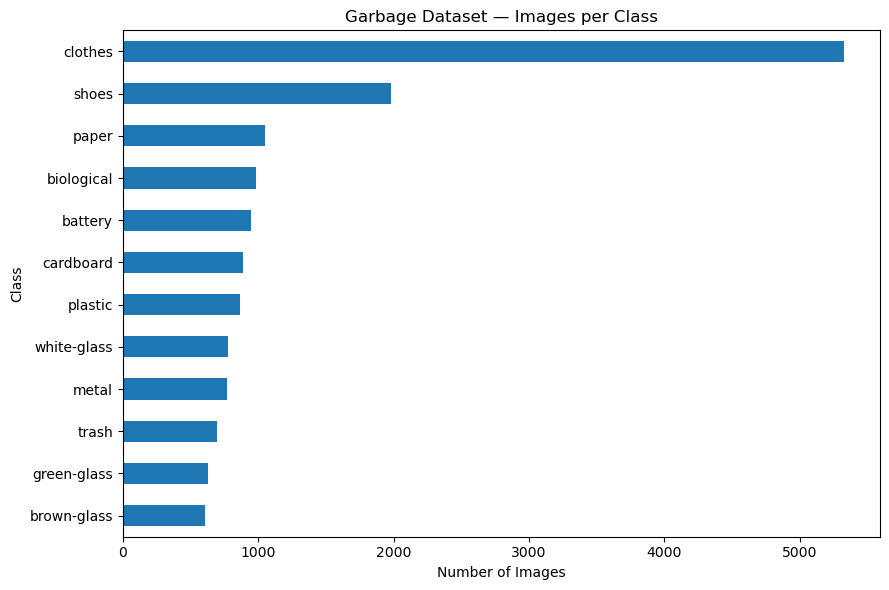

In [5]:
plt.figure(figsize=(9, 6))
class_counts.sort_values().plot(kind="barh")
plt.title("Garbage Dataset — Images per Class")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.2 Visual sample from the dataset</h3>
<p>Before preprocessing, always inspect real images. This catches wrong labels, unusual formats,
corrupted files, or unexpected visual patterns.</p>
    </div>

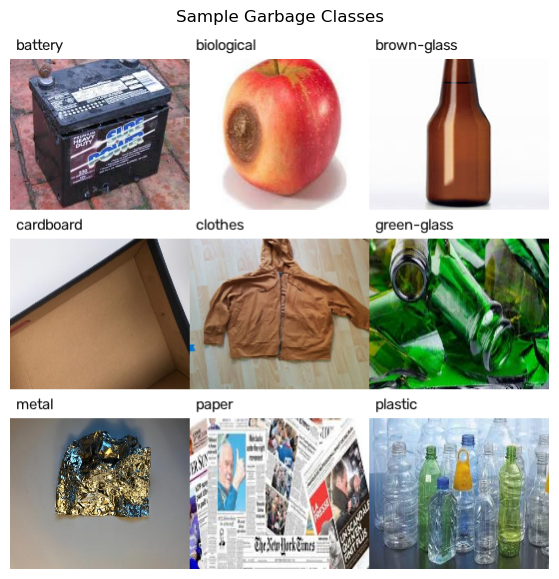

In [6]:
def add_label_to_rgb(image_rgb, label):
    canvas = image_rgb.copy()
    cv2.rectangle(canvas, (0, 0), (canvas.shape[1], 28), (255, 255, 255), -1)
    cv2.putText(
        canvas,
        str(label)[:24],
        (6, 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (20, 20, 20),
        1,
        cv2.LINE_AA,
    )
    return canvas

def make_montage(images_rgb, labels=None, columns=3, tile_size=(180, 180)):
    tiles = []
    labels = labels or [""] * len(images_rgb)

    for image, label in zip(images_rgb, labels):
        tile = cv2.resize(image, tile_size)
        tile = add_label_to_rgb(tile, label)
        tiles.append(tile)

    rows = []
    for start in range(0, len(tiles), columns):
        row_tiles = tiles[start:start + columns]
        while len(row_tiles) < columns:
            row_tiles.append(np.full_like(tiles[0], 255))
        rows.append(np.hstack(row_tiles))

    return np.vstack(rows)

sample_rows = (
    image_df.groupby("class_name", group_keys=False)
    .sample(n=1, random_state=SEED)
    .head(9)
)

sample_images = []
sample_labels = []

for _, row in sample_rows.iterrows():
    bgr = cv2.imread(row["path"])
    if bgr is None:
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    sample_images.append(rgb)
    sample_labels.append(row["class_name"])

montage = make_montage(sample_images, sample_labels, columns=3)

plt.figure(figsize=(10, 7))
plt.imshow(montage)
plt.axis("off")
plt.title("Sample Garbage Classes")
plt.show()

<a id="section3"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    3. Why Images Need Preprocessing
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 Raw images are not automatically consistent</h3>
<p>Real datasets may contain images with different:</p>
<ul>
<li>widths and heights,</li>
<li>color/channel formats,</li>
<li>pixel ranges,</li>
<li>lighting, orientation, and scale.</li>
</ul>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.2 What the model needs</h3>

<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Different Raw Images
        ↓
Standardization
        ↓
Same Size
Same Channel Format
Same Pixel Range
        ↓
Consistent Model Input</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Key idea:</b> Image preprocessing reduces irrelevant input differences so the model can focus on the visual patterns that matter.
    </div>
    </div>

In [7]:
# Inspect image dimensions on a manageable sample.
audit_n = min(500, len(image_df))
audit_paths = image_df.sample(n=audit_n, random_state=SEED)["path"]

size_rows = []

for path in audit_paths:
    image = cv2.imread(path)
    if image is None:
        continue

    height, width = image.shape[:2]
    channels = 1 if image.ndim == 2 else image.shape[2]
    size_rows.append((width, height, channels))

size_df = pd.DataFrame(
    size_rows,
    columns=["width", "height", "channels"]
)

print("Images audited:", len(size_df))
print("Unique (width, height) combinations:", size_df[["width", "height"]].drop_duplicates().shape[0])

display(
    size_df.value_counts(["width", "height"])
    .head(10)
    .to_frame("count")
)

Images audited: 500
Unique (width, height) combinations: 137


count
width height       
512   384        83
400   533        80
225   225        66
400   534        28
275   183        19
259   194        15
533   400        10
400   711         9
      400         7
300   168         7

<a id="section4"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    4. OpenCV Fundamentals
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.1 Core OpenCV operations</h3>
<table>
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;">Operation</th>
<th style="color:white;">Purpose</th>
</tr>
<tr><td><b>Read</b></td><td>Load an image from disk.</td></tr>
<tr><td><b>Resize</b></td><td>Standardize image dimensions.</td></tr>
<tr><td><b>Color conversion</b></td><td>Switch between BGR, RGB, and grayscale.</td></tr>
<tr><td><b>Normalization</b></td><td>Scale pixel values into a model-friendly range.</td></tr>
<tr><td><b>Edge detection</b></td><td>Highlight strong boundaries for classical feature work.</td></tr>
</table>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.2 Core Day 3 pipeline</h3>

<div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">image = cv2.imread(path)
image = cv2.resize(image, (224, 224))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype("float32") / 255.0</div>
    </div>

<a id="section5"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    5. Read & Resize Images
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.1 Read one real garbage image</h3>
<p><code>cv2.imread()</code> loads an image into a NumPy array.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.2 Resize</h3>
<p>A CNN expects fixed spatial dimensions inside a batch. For this notebook we use:</p>


<div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Target size = 224 × 224</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>OpenCV detail:</b> <code>cv2.resize()</code> receives size as <code>(width, height)</code>.
    </div>
    </div>

In [8]:
sample_path = Path(
    image_df.sample(n=1, random_state=SEED).iloc[0]["path"]
)

image_bgr = cv2.imread(str(sample_path))

if image_bgr is None:
    raise ValueError(f"OpenCV could not read: {sample_path}")

print("Path        :", sample_path)
print("Original shape:", image_bgr.shape)
print("Data type   :", image_bgr.dtype)
print("Pixel range :", image_bgr.min(), "to", image_bgr.max())

Path        : garbage_classification\plastic\plastic599.jpg
Original shape: (170, 297, 3)
Data type   : uint8
Pixel range : 0 to 255


In [9]:
TARGET_SIZE = (224, 224)

resized_bgr = cv2.resize(image_bgr, TARGET_SIZE)

print("Before:", image_bgr.shape)
print("After :", resized_bgr.shape)

Before: (170, 297, 3)
After : (224, 224, 3)


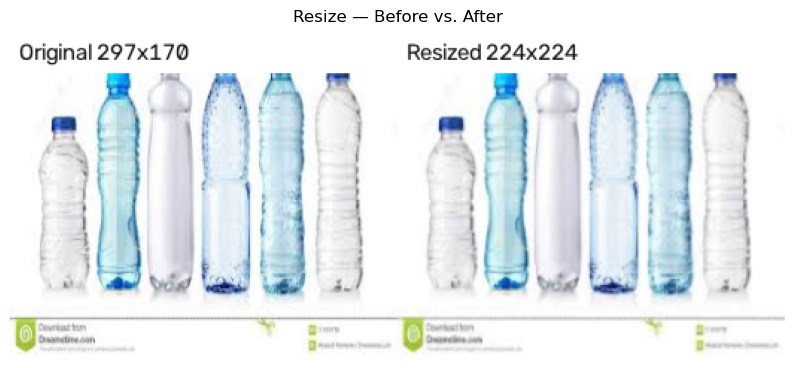

In [10]:
comparison_rgb = [
    cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB),
]

comparison_labels = [
    f"Original {image_bgr.shape[1]}x{image_bgr.shape[0]}",
    "Resized 224x224",
]

resize_montage = make_montage(
    comparison_rgb,
    comparison_labels,
    columns=2,
    tile_size=(260, 220),
)

plt.figure(figsize=(10, 4.5))
plt.imshow(resize_montage)
plt.axis("off")
plt.title("Resize — Before vs. After")
plt.show()

<a id="section6"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    6. BGR vs. RGB
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 The OpenCV color-order pitfall</h3>
<p>OpenCV reads standard color images in <b>BGR</b> channel order, while matplotlib displays arrays as <b>RGB</b>.</p>


<div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">OpenCV image
B G R
  ↓
cv2.cvtColor(..., cv2.COLOR_BGR2RGB)
  ↓
R G B</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Classic bug:</b> Displaying a BGR image directly with matplotlib silently swaps red and blue, making the colors look wrong.
    </div>
    </div>

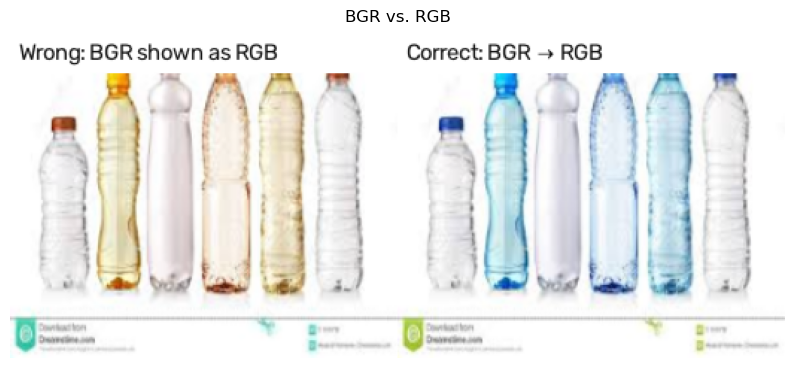

In [11]:
image_rgb = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)

# First tile intentionally passes BGR to matplotlib as if it were RGB.
bgr_vs_rgb = make_montage(
    [resized_bgr, image_rgb],
    ["Wrong: BGR shown as RGB", "Correct: BGR → RGB"],
    columns=2,
    tile_size=(260, 220),
)

plt.figure(figsize=(10, 4.5))
plt.imshow(bgr_vs_rgb)
plt.axis("off")
plt.title("BGR vs. RGB")
plt.show()

<a id="section7"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    7. Normalization
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.1 Pixel values before normalization</h3>
<p>Standard 8-bit images usually contain integer pixel values from <b>0 to 255</b>.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.2 Generic normalization</h3>

<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">0–255
  ↓ divide by 255.0
0–1</div>


<p>Generic normalization is simple and useful for many custom pipelines.</p>


<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Important:</b> Transfer-learning models may expect a different preprocessing rule. We will handle that separately in Section 11.
    </div>
    </div>

In [12]:
image_rgb_float = image_rgb.astype("float32")
image_normalized = image_rgb_float / 255.0

print("Before normalization:")
print(" dtype:", image_rgb_float.dtype)
print(" range:", image_rgb_float.min(), "to", image_rgb_float.max())

print("\nAfter normalization:")
print(" dtype:", image_normalized.dtype)
print(" range:", image_normalized.min(), "to", image_normalized.max())

Before normalization:
 dtype: float32
 range: 0.0 to 255.0

After normalization:
 dtype: float32
 range: 0.0 to 1.0


In [13]:
row, col = 50, 50

print("Example pixel before:", image_rgb_float[row, col])
print("Example pixel after :", np.round(image_normalized[row, col], 4))

Example pixel before: [249. 254. 253.]
Example pixel after : [0.9765 0.9961 0.9922]


<a id="section8"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    8. Edge Detection
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.1 Why include edge detection?</h3>
<p>Edge detection is a classic OpenCV operation that highlights strong intensity changes and object boundaries.
It is useful for understanding traditional computer vision, even though modern CNNs learn many edge-like features automatically.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.2 Canny edges</h3>

<div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">RGB / BGR image
      ↓
Grayscale
      ↓
Canny Edge Detection
      ↓
Boundary Map</div>
    </div>

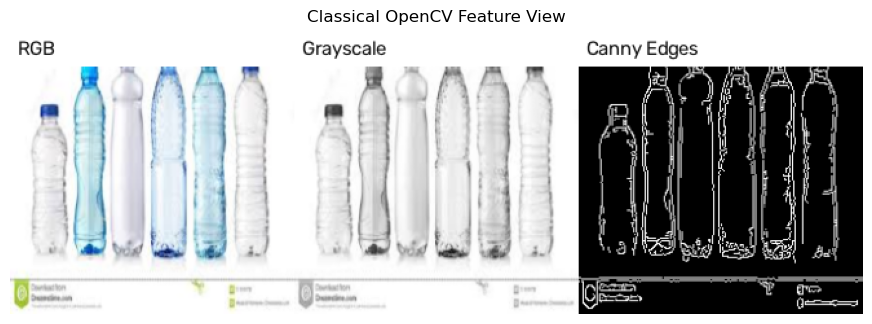

In [14]:
gray = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

edge_montage = make_montage(
    [image_rgb, gray_rgb, edges_rgb],
    ["RGB", "Grayscale", "Canny Edges"],
    columns=3,
    tile_size=(220, 220),
)

plt.figure(figsize=(11, 4))
plt.imshow(edge_montage)
plt.axis("off")
plt.title("Classical OpenCV Feature View")
plt.show()

<a id="hands-on"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    Hands-On Lab Starts From Here
</h2>

<a id="section9"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    9. Full OpenCV Preprocessing Function
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.1 Build one reusable function</h3>
<p>Now we combine the Day 3 fundamentals into one clean preprocessing function:</p>


<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Read
 ↓
Resize
 ↓
BGR → RGB
 ↓
float32
 ↓
Normalize to 0–1
 ↓
Model-ready array</div>
    </div>

In [15]:
def preprocess_image(
    path,
    target_size=(224, 224),
    normalize=True,
):
    """Read, resize, convert BGR→RGB, and optionally normalize one image."""

    image_bgr = cv2.imread(str(path))

    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    image_bgr = cv2.resize(image_bgr, target_size)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb = image_rgb.astype("float32")

    if normalize:
        image_rgb = image_rgb / 255.0

    return image_rgb

In [16]:
processed = preprocess_image(sample_path)

print("Processed shape:", processed.shape)
print("Processed dtype:", processed.dtype)
print("Processed range:", processed.min(), "to", processed.max())

Processed shape: (224, 224, 3)
Processed dtype: float32
Processed range: 0.0 to 1.0


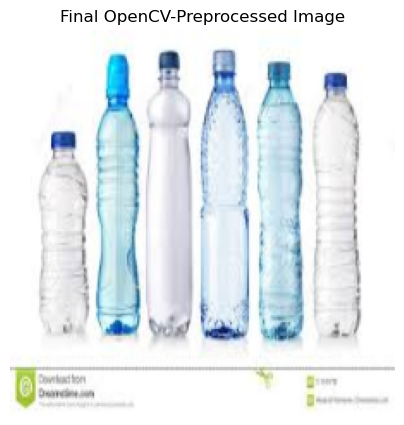

In [17]:
processed_display = np.clip(processed * 255, 0, 255).astype("uint8")

plt.figure(figsize=(5, 5))
plt.imshow(processed_display)
plt.axis("off")
plt.title("Final OpenCV-Preprocessed Image")
plt.show()

<a id="section10"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    10. Data Augmentation Pipeline
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.1 Why augmentation?</h3>
<p>Augmentation creates realistic variations of training images <b>on the fly</b>.
It helps the model depend less on one exact orientation, crop, brightness, or position.</p>


<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">One Training Image
       ↓
Rotate / Zoom / Flip / Brightness
       ↓
Multiple Visual Variations
       ↓
Less Memorization
       ↓
Better Generalization</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.2 Day 3 augmentation settings</h3>

<div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">rotation_range = 20
zoom_range = 0.15
horizontal_flip = True
brightness_range = [0.8, 1.2]
rescale = 1./255</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Rule:</b> Apply augmentation to the training set only — not validation or test data.
    </div>
    </div>

In [18]:
# TensorFlow/Keras is optional for the notebook to open and run.
# If available, we use the ImageDataGenerator requested by the Day 3 curriculum.

try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    TENSORFLOW_AVAILABLE = True
    print("TensorFlow/Keras available.")
except ModuleNotFoundError:
    TENSORFLOW_AVAILABLE = False
    print(
        "TensorFlow is not installed in this environment. "
        "The notebook will use a small OpenCV fallback only for visualization."
    )

TensorFlow/Keras available.


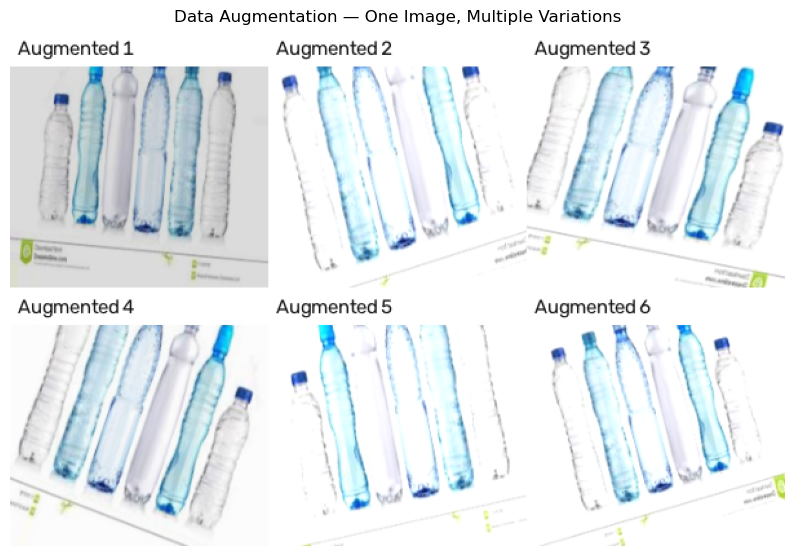

In [19]:
# Prepare one RGB uint8 image for augmentation.
augmentation_source = cv2.cvtColor(
    cv2.resize(cv2.imread(str(sample_path)), TARGET_SIZE),
    cv2.COLOR_BGR2RGB,
)

augmented_images = []
augmented_labels = []

if TENSORFLOW_AVAILABLE:
    datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        rescale=1.0 / 255.0,
    )

    batch = np.expand_dims(
        augmentation_source.astype("float32"),
        axis=0,
    )

    flow = datagen.flow(
        batch,
        batch_size=1,
        shuffle=False,
        seed=SEED,
    )

    for i in range(6):
        aug = next(flow)[0]
        aug = np.clip(aug * 255, 0, 255).astype("uint8")
        augmented_images.append(aug)
        augmented_labels.append(f"Augmented {i + 1}")

else:
    # Lightweight OpenCV fallback so the visual explanation still works.
    h, w = augmentation_source.shape[:2]
    center = (w // 2, h // 2)

    transforms = [
        ("Original", augmentation_source),
        ("Flip", cv2.flip(augmentation_source, 1)),
    ]

    for angle in [-15, 15]:
        matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(
            augmentation_source,
            matrix,
            (w, h),
            borderMode=cv2.BORDER_REFLECT,
        )
        transforms.append((f"Rotate {angle}°", rotated))

    darker = np.clip(augmentation_source.astype("float32") * 0.8, 0, 255).astype("uint8")
    brighter = np.clip(augmentation_source.astype("float32") * 1.2, 0, 255).astype("uint8")

    transforms.extend([
        ("Brightness 0.8", darker),
        ("Brightness 1.2", brighter),
    ])

    augmented_labels, augmented_images = zip(*transforms)
    augmented_labels = list(augmented_labels)
    augmented_images = list(augmented_images)

augmentation_montage = make_montage(
    augmented_images,
    augmented_labels,
    columns=3,
    tile_size=(200, 200),
)

plt.figure(figsize=(10, 7))
plt.imshow(augmentation_montage)
plt.axis("off")
plt.title("Data Augmentation — One Image, Multiple Variations")
plt.show()

<a id="section11"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    11. Transfer Learning Preprocessing
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.1 Why generic normalization is not always enough</h3>
<p>A pre-trained model was originally trained with a specific input preprocessing rule.
When using transfer learning, we should match that exact expectation.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.2 Example: MobileNetV2</h3>
<p>MobileNetV2 uses a preprocessing function that scales RGB pixel values into approximately <b>-1 to 1</b>.</p>


<div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Raw RGB pixels: 0–255
        ↓
MobileNetV2 preprocess_input
        ↓
Approximately -1 to 1</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Important:</b> Do not divide by 255 first and then call a model-specific <code>preprocess_input</code> unless that model explicitly expects it. That would be double preprocessing.
    </div>
    </div>

In [20]:
# Start from resized RGB pixels in the original 0–255 scale.
transfer_rgb = cv2.cvtColor(
    cv2.resize(cv2.imread(str(sample_path)), TARGET_SIZE),
    cv2.COLOR_BGR2RGB,
).astype("float32")

if TENSORFLOW_AVAILABLE:
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    transfer_ready = preprocess_input(transfer_rgb.copy())
    method_used = "tensorflow.keras.applications.mobilenet_v2.preprocess_input"

else:
    # MobileNetV2's standard scaling is equivalent to x / 127.5 - 1.
    transfer_ready = transfer_rgb / 127.5 - 1.0
    method_used = "Manual MobileNetV2-equivalent scaling for demonstration"

print("Method:", method_used)
print("Input range :", transfer_rgb.min(), "to", transfer_rgb.max())
print("Output range:", round(float(transfer_ready.min()), 4), "to", round(float(transfer_ready.max()), 4))
print("Shape       :", transfer_ready.shape)

Method: tensorflow.keras.applications.mobilenet_v2.preprocess_input
Input range : 0.0 to 255.0
Output range: -1.0 to 1.0
Shape       : (224, 224, 3)


<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.3 Generic preprocessing vs. model-specific preprocessing</h3>
<table>
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;">Pipeline</th>
<th style="color:white;">Typical Range</th>
<th style="color:white;">Use Case</th>
</tr>
<tr><td>Generic <code>/255.0</code></td><td>0 to 1</td><td>Custom model / custom training pipeline</td></tr>
<tr><td>MobileNetV2 <code>preprocess_input</code></td><td>Approximately -1 to 1</td><td>MobileNetV2 transfer learning</td></tr>
</table>
    </div>

<a id="section12"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    12. Validate the Pipeline
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.1 Preprocess several real images</h3>
<p>A professional preprocessing pipeline should be checked before training:</p>
<ul>
<li>Every output must have the same shape.</li>
<li>The dtype should be correct.</li>
<li>The pixel range should match the chosen pipeline.</li>
<li>No image should fail silently.</li>
</ul>
    </div>

In [21]:
validation_sample = image_df.sample(
    n=min(20, len(image_df)),
    random_state=SEED,
)

checks = []

for _, row in validation_sample.iterrows():
    try:
        img = preprocess_image(row["path"])
        checks.append({
            "class_name": row["class_name"],
            "shape": img.shape,
            "dtype": str(img.dtype),
            "min": float(img.min()),
            "max": float(img.max()),
            "status": "OK",
        })
    except Exception as error:
        checks.append({
            "class_name": row["class_name"],
            "shape": None,
            "dtype": None,
            "min": None,
            "max": None,
            "status": f"ERROR: {error}",
        })

validation_df = pd.DataFrame(checks)
display(validation_df.head(10))

,class_name,shape,dtype,min,max,status
0,plastic,"(224, 224, 3)",float32,0.000000,1.000000,OK
1,biological,"(224, 224, 3)",float32,0.000000,0.945098,OK
2,green-glass,"(224, 224, 3)",float32,0.000000,0.996078,OK
3,clothes,"(224, 224, 3)",float32,0.000000,1.000000,OK
4,shoes,"(224, 224, 3)",float32,0.000000,1.000000,OK
5,white-glass,"(224, 224, 3)",float32,0.000000,1.000000,OK
6,metal,"(224, 224, 3)",float32,0.019608,0.909804,OK
7,clothes,"(224, 224, 3)",float32,0.000000,0.992157,OK
8,clothes,"(224, 224, 3)",float32,0.094118,1.000000,OK
9,metal,"(224, 224, 3)",float32,0.000000,1.000000,OK


In [22]:
expected_shape = (224, 224, 3)

all_shapes_ok = validation_df["shape"].dropna().apply(
    lambda shape: tuple(shape) == expected_shape
).all()

all_ranges_ok = (
    validation_df["min"].dropna().ge(0).all()
    and validation_df["max"].dropna().le(1).all()
)

no_errors = validation_df["status"].eq("OK").all()

print("All shapes are 224x224x3 :", all_shapes_ok)
print("All values are in 0–1   :", all_ranges_ok)
print("No preprocessing errors :", no_errors)

All shapes are 224x224x3 : True
All values are in 0–1   : True
No preprocessing errors : True


<a id="section13"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    13. Hands-On Lab Summary
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">13.1 Day 3 hands-on requirements</h3>
<ul>
<li> - Build an OpenCV preprocessing function: read, resize, convert to RGB, normalize.</li>
<li> - Build an augmentation pipeline and visualize multiple versions of one image.</li>
<li> - Apply model-specific preprocessing for a selected pre-trained model (MobileNetV2 example).</li>

</ul>



<a id="section14"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    14. What I Learned Today
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <ul>
<li><b>Image preprocessing:</b> Why raw images need standardization before model training.</li>
<li><b>OpenCV:</b> How to read and manipulate image arrays.</li>
<li><b>Resize:</b> How to make all images use fixed dimensions.</li>
<li><b>BGR vs. RGB:</b> Why OpenCV color order must be handled correctly.</li>
<li><b>Normalization:</b> How to scale pixels from 0–255 to 0–1 for a generic pipeline.</li>
<li><b>Edge detection:</b> How Canny highlights strong visual boundaries.</li>
<li><b>Reusable pipeline:</b> How to combine reading, resizing, color conversion, and normalization in one function.</li>
<li><b>Data augmentation:</b> How rotation, zoom, flips, and brightness variations improve training diversity.</li>
<li><b>Generalization:</b> Why augmentation can reduce memorization and overfitting.</li>
<li><b>Transfer learning:</b> Why preprocessing must match the expectations of the pre-trained model.</li>
<li><b>MobileNetV2 preprocessing:</b> How model-specific preprocessing differs from simple 0–1 normalization.</li>
<li><b>Pipeline validation:</b> How to verify shape, dtype, ranges, and preprocessing errors before training.</li>

</ul>
    </div>

<a id="section15"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    15. Day 3 Mental Map
</h2>

<style>
.day3-card {
    background-color:#F8F8F8;
    color:#111111;
    border:1px solid #E9E9E9;
    border-radius:9px;
    padding:16px 18px;
    margin:10px 0 18px 0;
    line-height:1.7;
}
.day3-card p,
.day3-card li,
.day3-card td {
    color:#111111 !important;
}
.day3-card table {
    width:100%;
    border-collapse:collapse;
}
.day3-card th {
    padding:9px;
    border:1px solid #CBD5E1;
}
.day3-card td {
    padding:9px;
    border:1px solid #CBD5E1;
    background:#FFFFFF;
}
</style>

<div class="day3-card">
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">RAW GARBAGE IMAGE
        ↓
cv2.imread()
        ↓
RESIZE
224 × 224
        ↓
BGR → RGB
        ↓
CHOOSE PREPROCESSING
   ┌───────────────┐
   ↓               ↓
Generic /255   Model-specific
   ↓               ↓
 0–1          e.g. MobileNetV2
                   -1 to 1
   └───────┬───────┘
           ↓
TRAINING AUGMENTATION
Rotate / Zoom / Flip / Brightness
           ↓
MODEL-READY INPUT</div>

<div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Golden Rule:</b> A good computer vision pipeline makes input consistent, preserves useful visual information, and matches the model's expected preprocessing.
    </div>
    </div>